1. Created a directory to store the dataset

In [ ]:
!mkdir -p /content/data

2. Extracting the uploaded zip file into /data

In [ ]:
!unzip "/content/archive (1).zip" -d "/content/data"


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/sad/Training_65242339.jpg  
  inflating: /content/data/train/sad/Training_65267116.jpg  
  inflating: /content/data/train/sad/Training_65275626.jpg  
  inflating: /content/data/train/sad/Training_6529266.jpg  
  inflating: /content/data/train/sad/Training_65329617.jpg  
  inflating: /content/data/train/sad/Training_65338712.jpg  
  inflating: /content/data/train/sad/Training_65338797.jpg  
  inflating: /content/data/train/sad/Training_65387162.jpg  
  inflating: /content/data/train/sad/Training_65404494.jpg  
  inflating: /content/data/train/sad/Training_65426218.jpg  
  inflating: /content/data/train/sad/Training_65430136.jpg  
  inflating: /content/data/train/sad/Training_65437377.jpg  
  inflating: /content/data/train/sad/Training_6545735.jpg  
  inflating: /content/data/train/sad/Training_65463385.jpg  
  inflating: /content/data/train/sad/Training_65473985.jpg  
  inflating: /content/data/train/sad

3. Data path stored in a var, for further processing


In [ ]:
data_dir = "content/data"

4. Importing necesary libraries

In [ ]:
import os
import random
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

5. Extracting class labels into a list

In [ ]:
train_dir = "/content/data/train"
test_dir = "/content/data/test"

classes = sorted(
    d for d in os.listdir(train_dir)
    if (os.path.isdir(os.path.join(train_dir, d)))
)

print("Classes: ", classes)
print("Number of classes: ", len(classes))

Classes:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes:  7


6. Getting class wise file/image counts from both train and test

In [ ]:
train_counts = {}
for cls in classes:
  folder = os.path.join(train_dir, cls)
  train_counts[cls] = len([
      f for f in os.listdir(folder)
      if f.lower().endswith((".jpg", ".png", ".jpeg"))
  ])

In [ ]:
test_counts = {}
for cls in classes:
  folder = os.path.join(test_dir, cls)
  test_counts[cls] = len([
      f for f in os.listdir(folder)
      if f.lower().endswith((".jpg", ".png", ".jpeg"))
  ])

In [ ]:
print("Train Counts: ", train_counts)
print("Test counts: ", test_counts)

Train Counts:  {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test counts:  {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


7. Presenting images randomly from the dir for each class label

In [ ]:
def show_random_images(split_dir, cls_name, num=5):
  folder = os.path.join(split_dir, cls_name)
  images = [
      f for f in os.listdir(folder)
      if f.lower().endswith((".jpg", ".png", ".jpeg"))
  ]

  images = random.sample(images, min(num, len(images)))


  plt.figure(figsize=(12, 3))
  for i, img_name in enumerate(images):
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls_name)
  plt.show()

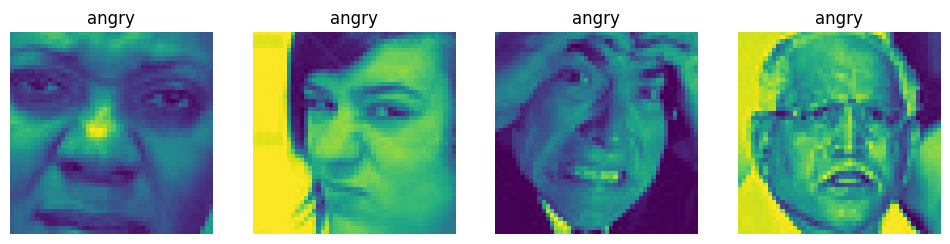

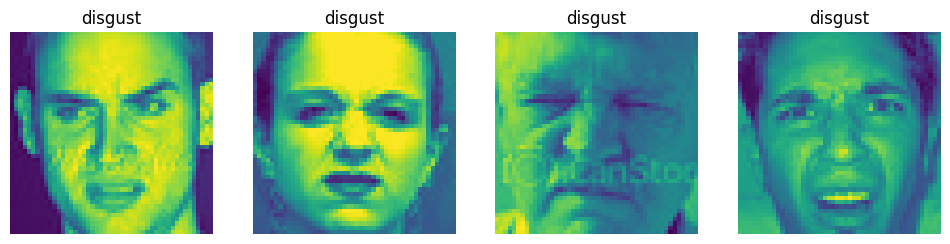

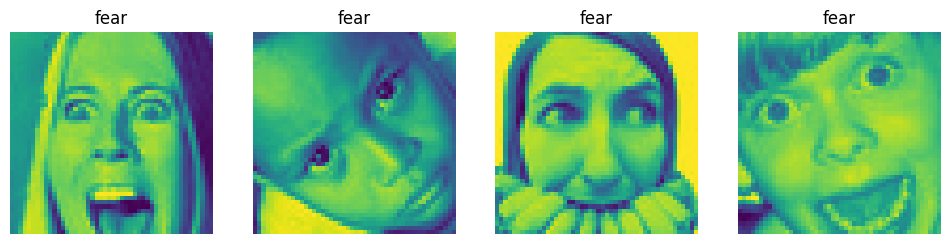

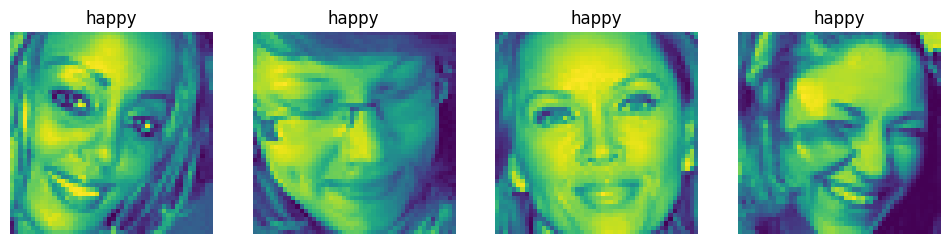

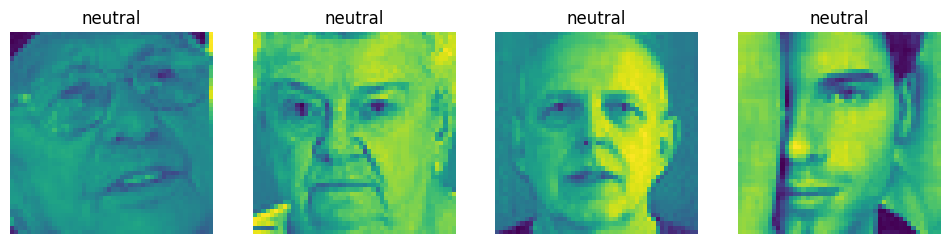

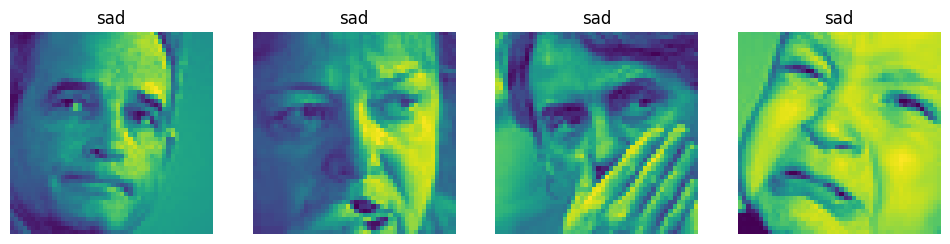

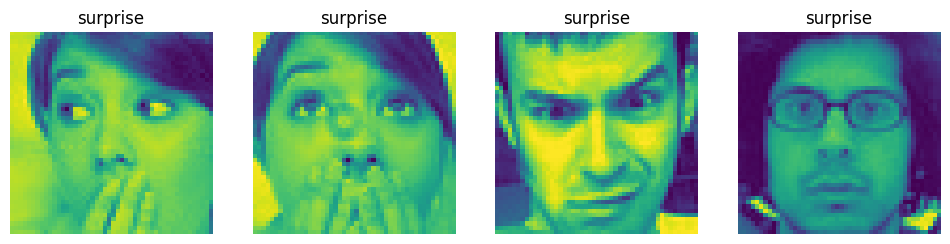

In [ ]:
for cls in classes:
  show_random_images(train_dir, cls, num=4)